# Avaliação do modelo de prioridade clínica — SIGPS Fila IA

**Tipo de problema:** classificação multiclasse (3 classes)

**Algoritmo:** `RandomForestClassifier` (150 árvores, `class_weight=balanced`)

**Classes (rótulos):**
- **1 — Normal:** adulto jovem/médio sem comorbidades relevantes
- **2 — Alta:** idoso (≥60) ou presença de diabetes/hipertensão
- **3 — Extrema:** câncer; ou idoso com comorbidade; ou >50 com diabetes e hipertensão

**Features:** `idade`, `tem_diabetes`, `tem_hipertensao`, `tem_cancer`, `organization_id`

**Pré-requisito:** rode `python -m src.train` nesta pasta antes de executar o notebook (gera `artifacts/model.pkl` e `artifacts/metrics.json`).

> O dataset é **sintético** (5000 amostras, 2% de ruído nos rótulos). Acurácia esperada ~98%. Os gráficos documentam o comportamento do modelo para o TCC.

In [ ]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split

from src.dataset import criar_dataset
from src.features import ORDEM_FEATURES

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

CLASSES = [1, 2, 3]
NOMES = {1: "Normal (1)", 2: "Alta (2)", 3: "Extrema (3)"}
ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)

## 1. Carregar dados e treinar (ou carregar modelo salvo)

In [ ]:
# Mesmos parâmetros de src/train.py
X, y = criar_dataset(n_samples=5000, ruido_rotulo=0.02)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

modelo_path = ARTIFACTS / "model.pkl"
metrics_path = ARTIFACTS / "metrics.json"

if not modelo_path.exists():
    raise FileNotFoundError(
        "Modelo não encontrado. Execute no terminal: python -m src.train"
    )

modelo = joblib.load(modelo_path)
print(f"Modelo carregado: {modelo_path}")

if metrics_path.exists():
    with open(metrics_path, encoding="utf-8") as f:
        metricas_treino = json.load(f)
    print("Métricas do último treino (artifacts/metrics.json):")
    print(json.dumps({k: metricas_treino[k] for k in ("accuracy", "f1_macro", "recall_extrema", "n_treino", "n_teste")}, indent=2))

y_pred = modelo.predict(X_teste)
y_proba = modelo.predict_proba(X_teste)

print(f"\nAmostras treino: {len(X_treino)} | teste: {len(X_teste)}")
print(f"Distribuição classes (teste): {pd.Series(y_teste).value_counts().sort_index().to_dict()}")

Modelo carregado: artifacts\model.pkl
Métricas do último treino (artifacts/metrics.json):
{
  "accuracy": 0.984,
  "f1_macro": 0.9829,
  "recall_extrema": 0.9837,
  "n_treino": 4000,
  "n_teste": 1000
}

Amostras treino: 4000 | teste: 1000
Distribuição classes (teste): {1: 302, 2: 452, 3: 246}


## 2. Métricas recomendadas para classificação multiclasse

| Métrica | Uso no SIGPS |
|---------|----------------|
| **Acurácia** | Proporção total de acertos (cuidado com classes desbalanceadas) |
| **Precisão (por classe)** | Dos classificados como Extrema, quantos realmente eram Extrema |
| **Recall / Sensibilidade** | Dos casos Extrema reais, quantos o modelo detectou (**crítico em saúde**) |
| **F1-score** | Média harmônica precisão/recall por classe |
| **Matriz de confusão** | Onde o modelo erra (ex.: Extrema classificada como Normal) |
| **Macro / Weighted F1** | Resumo global considerando todas as classes |

In [3]:
acc = accuracy_score(y_teste, y_pred)
prec_macro = precision_score(y_teste, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_teste, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_teste, y_pred, average="macro", zero_division=0)
f1_weighted = f1_score(y_teste, y_pred, average="weighted", zero_division=0)

metricas = {
    "accuracy": round(acc, 4),
    "precision_macro": round(prec_macro, 4),
    "recall_macro": round(rec_macro, 4),
    "f1_macro": round(f1_macro, 4),
    "f1_weighted": round(f1_weighted, 4),
    "n_teste": int(len(y_teste)),
    "modelo": type(modelo).__name__,
}
print(json.dumps(metricas, indent=2))
print("\n", classification_report(y_teste, y_pred, target_names=[NOMES[c] for c in CLASSES]))

{
  "accuracy": 0.984,
  "precision_macro": 0.9839,
  "recall_macro": 0.9821,
  "f1_macro": 0.9829,
  "f1_weighted": 0.984,
  "n_teste": 1000,
  "modelo": "RandomForestClassifier"
}

               precision    recall  f1-score   support

  Normal (1)       0.98      0.97      0.97       302
    Alta (2)       0.98      1.00      0.99       452
 Extrema (3)       0.98      0.98      0.98       246

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



## 3. Matriz de confusão

Gráfico **essencial** para classificação. Mostra falsos positivos/negativos por classe.
Em fila hospitalar, o erro mais grave é **Extrema → Normal** (canto inferior direito se classes ordenadas 1→3).

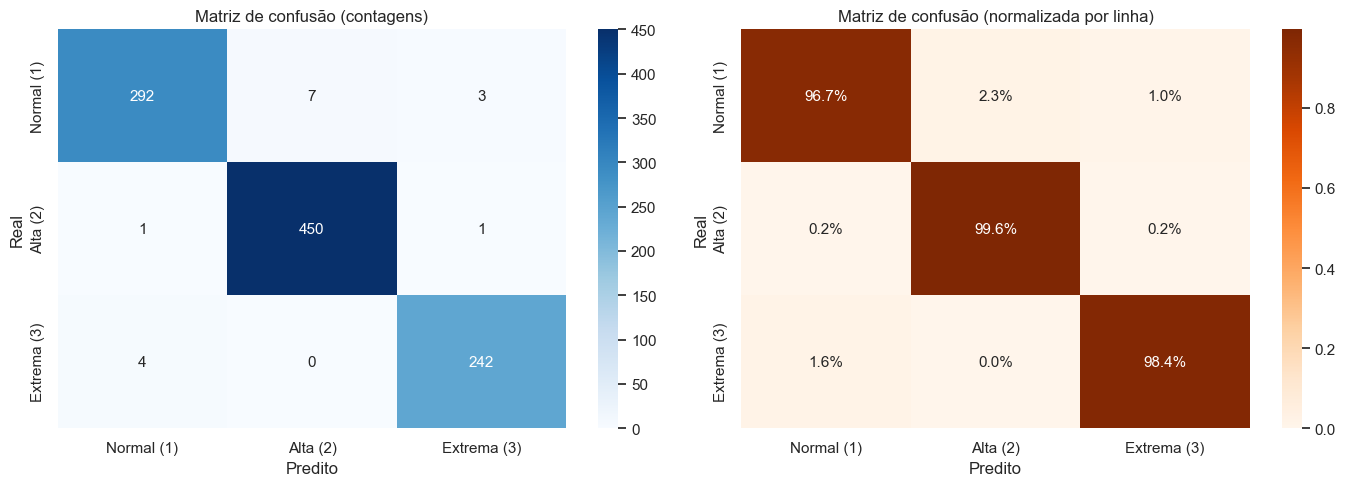

In [4]:
cm = confusion_matrix(y_teste, y_pred, labels=CLASSES)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = [NOMES[c] for c in CLASSES]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")
axes[0].set_title("Matriz de confusão (contagens)")

sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Oranges", xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_xlabel("Predito")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de confusão (normalizada por linha)")

plt.tight_layout()
plt.savefig(ARTIFACTS / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Taxas de erro por classe

Útil para o TCC: deixa explícito **qual prioridade** o modelo erra mais.

,classe,total,acertos,erros,taxa_erro,taxa_acerto
0,Normal (1),302,292,10,0.033113,0.966887
1,Alta (2),452,450,2,0.004425,0.995575
2,Extrema (3),246,242,4,0.016260,0.983740


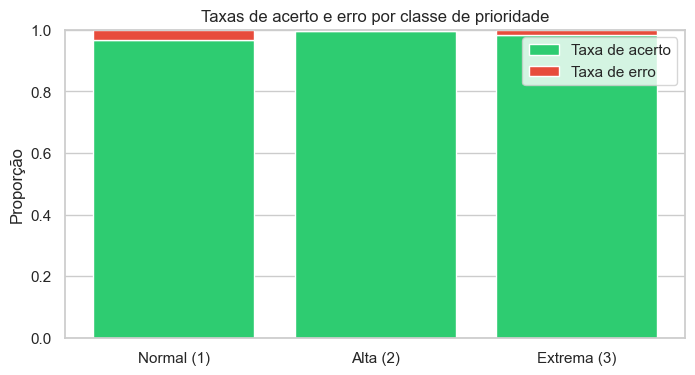

In [5]:
taxas = []
for i, c in enumerate(CLASSES):
    total = cm[i].sum()
    erros = total - cm[i, i]
    taxas.append({
        "classe": NOMES[c],
        "total": int(total),
        "acertos": int(cm[i, i]),
        "erros": int(erros),
        "taxa_erro": erros / total if total else 0,
        "taxa_acerto": cm[i, i] / total if total else 0,
    })

df_taxas = pd.DataFrame(taxas)
display(df_taxas)

fig, ax = plt.subplots(figsize=(8, 4))
x = df_taxas["classe"]
ax.bar(x, df_taxas["taxa_acerto"], label="Taxa de acerto", color="#2ecc71")
ax.bar(x, df_taxas["taxa_erro"], bottom=df_taxas["taxa_acerto"], label="Taxa de erro", color="#e74c3c")
ax.set_ylim(0, 1)
ax.set_ylabel("Proporção")
ax.set_title("Taxas de acerto e erro por classe de prioridade")
ax.legend()
plt.savefig(ARTIFACTS / "taxas_erro_classe.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Probabilidades preditas (`predict_proba`)

Random Forest retorna probabilidade por classe. Gráficos úteis:
- **Distribuição da prob. máxima:** confiança do modelo
- **Violin/box por classe real:** separabilidade das classes
- **Heatmap médio de probabilidades:** padrão de decisão

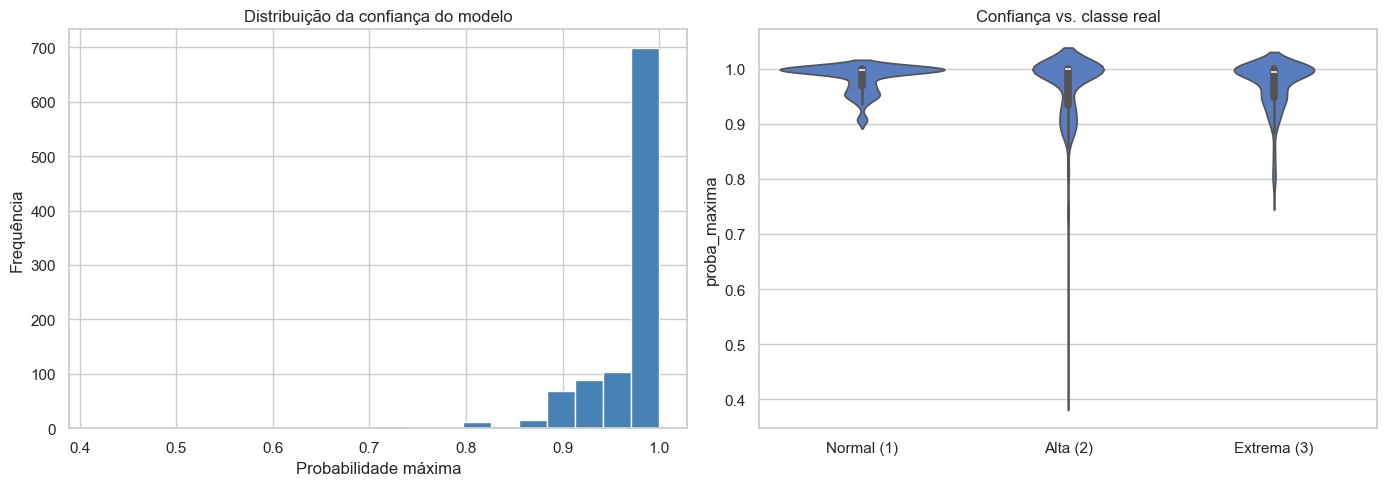

In [6]:
proba_max = y_proba.max(axis=1)
classe_pred = modelo.classes_[y_proba.argmax(axis=1)]

df_proba = pd.DataFrame(y_proba, columns=[f"P({NOMES[c]})" for c in modelo.classes_])
df_proba["classe_real"] = [NOMES[c] for c in y_teste]
df_proba["proba_maxima"] = proba_max

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(proba_max, bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Probabilidade máxima")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da confiança do modelo")

sns.violinplot(data=df_proba, x="classe_real", y="proba_maxima", ax=axes[1], order=[NOMES[c] for c in CLASSES])
axes[1].set_title("Confiança vs. classe real")
axes[1].set_xlabel("")

plt.tight_layout()
plt.savefig(ARTIFACTS / "distribuicao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

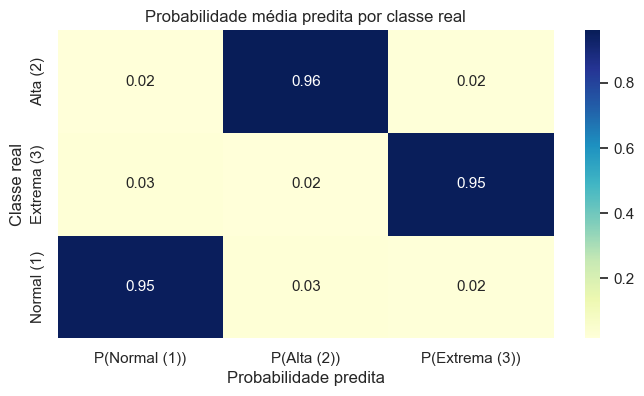

In [7]:
proba_media = df_proba.groupby("classe_real").mean(numeric_only=True)
cols_proba = [c for c in proba_media.columns if c.startswith("P(")]

plt.figure(figsize=(8, 4))
sns.heatmap(proba_media[cols_proba], annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Probabilidade média predita por classe real")
plt.ylabel("Classe real")
plt.xlabel("Probabilidade predita")
plt.savefig(ARTIFACTS / "heatmap_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Limiares de decisão (análise multiclasse)

Na API atual a decisão é `argmax(probabilidades)` — equivalente a limiar 0.33 em 3 classes equilibradas.

Para **priorizar segurança clínica**, pode-se exigir limiar mínimo para classificar como Normal, ou
promover para Extrema se `P(Extrema) >= limiar`. O gráfico abaixo simula: *quantos casos Extrema reais seriam capturados vs. falsos alarmes*.

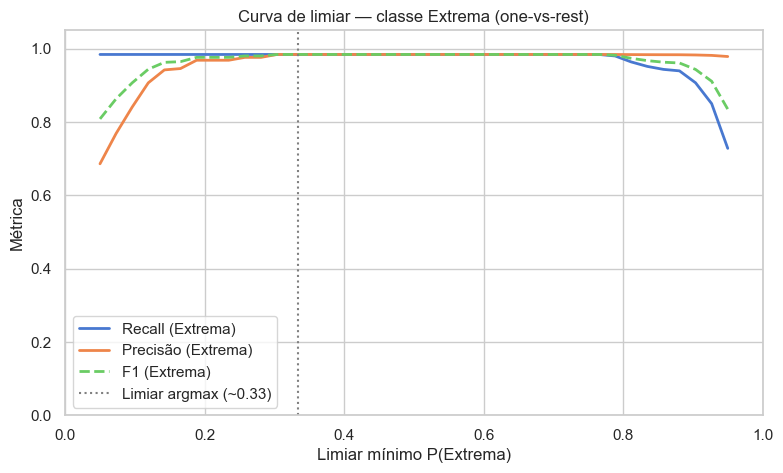

In [8]:
idx_extrema = list(modelo.classes_).index(3)
p_extrema = y_proba[:, idx_extrema]
y_real_extrema = (y_teste == 3).astype(int)

limiares = np.linspace(0.05, 0.95, 40)
recalls, precisions, f1s = [], [], []

for t in limiares:
    y_bin = (p_extrema >= t).astype(int)
    rec = recall_score(y_real_extrema, y_bin, zero_division=0)
    prec = precision_score(y_real_extrema, y_bin, zero_division=0)
    f1 = f1_score(y_real_extrema, y_bin, zero_division=0)
    recalls.append(rec)
    precisions.append(prec)
    f1s.append(f1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(limiares, recalls, label="Recall (Extrema)", linewidth=2)
ax.plot(limiares, precisions, label="Precisão (Extrema)", linewidth=2)
ax.plot(limiares, f1s, label="F1 (Extrema)", linewidth=2, linestyle="--")
ax.axvline(1/3, color="gray", linestyle=":", label="Limiar argmax (~0.33)")
ax.set_xlabel("Limiar mínimo P(Extrema)")
ax.set_ylabel("Métrica")
ax.set_title("Curva de limiar — classe Extrema (one-vs-rest)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
plt.savefig(ARTIFACTS / "curva_limiar_extrema.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Importância das features

Complementar ao TCC: mostra quais variáveis o Random Forest mais usa.

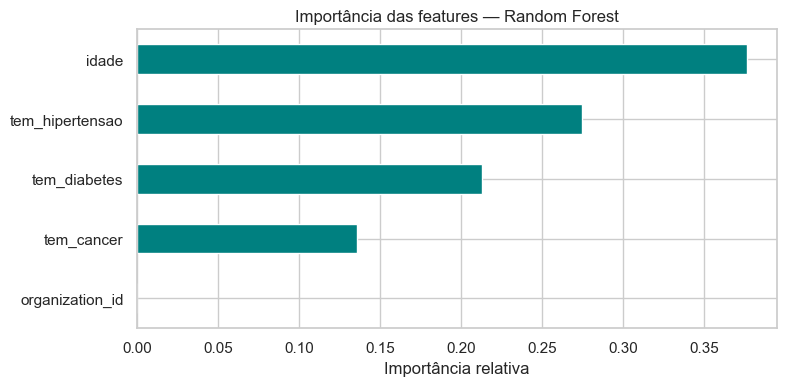

In [9]:
imp = pd.Series(modelo.feature_importances_, index=ORDEM_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
imp.plot(kind="barh", color="teal")
plt.title("Importância das features — Random Forest")
plt.xlabel("Importância relativa")
plt.tight_layout()
plt.savefig(ARTIFACTS / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Casos de teste alinhados ao seed da clínica demo

Simula os pacientes criados em `SIGPS-Backend/scripts/seed_fila_ia_test.py`.

In [10]:
casos_demo = pd.DataFrame([
    {"paciente": "Lucas Normal", "idade": 28, "tem_diabetes": 0, "tem_hipertensao": 0, "tem_cancer": 0, "organization_id": 1},
    {"paciente": "Mariana Alta", "idade": 45, "tem_diabetes": 1, "tem_hipertensao": 0, "tem_cancer": 0, "organization_id": 1},
    {"paciente": "José Extrema", "idade": 72, "tem_diabetes": 1, "tem_hipertensao": 1, "tem_cancer": 0, "organization_id": 1},
    {"paciente": "Ana Extrema", "idade": 55, "tem_diabetes": 0, "tem_hipertensao": 0, "tem_cancer": 1, "organization_id": 1},
    {"paciente": "Carlos Alta", "idade": 65, "tem_diabetes": 0, "tem_hipertensao": 0, "tem_cancer": 0, "organization_id": 1},
])

X_demo = casos_demo[ORDEM_FEATURES].to_numpy(dtype=np.float32)
pred_demo = modelo.predict(X_demo)
proba_demo = modelo.predict_proba(X_demo)

casos_demo["prioridade_predita"] = pred_demo
casos_demo["P(Normal)"] = proba_demo[:, list(modelo.classes_).index(1)]
casos_demo["P(Alta)"] = proba_demo[:, list(modelo.classes_).index(2)]
casos_demo["P(Extrema)"] = proba_demo[:, list(modelo.classes_).index(3)]
casos_demo

,paciente,idade,tem_diabetes,tem_hipertensao,tem_cancer,organization_id,prioridade_predita,P(Normal),P(Alta),P(Extrema)
0,Lucas Normal,28,0,0,0,1,1,0.996122,0.001223,0.002656
1,Mariana Alta,45,1,0,0,1,2,0.000338,0.998012,0.001650
2,José Extrema,72,1,1,0,1,3,0.000617,0.000000,0.999383
3,Ana Extrema,55,0,0,1,1,3,0.006667,0.000000,0.993333
4,Carlos Alta,65,0,0,0,1,2,0.044334,0.955180,0.000485


## Resumo para o TCC

**Gráficos recomendados (implementados acima):**
1. Matriz de confusão (contagem + normalizada) — obrigatório
2. Taxas de erro por classe — claro para banca
3. Distribuição / violino de probabilidades — mostra confiança do RF
4. Curva de limiar (one-vs-rest Extrema) — discussão de política clínica
5. Importância de features — interpretabilidade

**Evitar para este modelo:** MAE/R² (métricas de regressão); o notebook antigo `teste.ipynb` usava regressão e conflita com o pipeline oficial.

**Figuras salvas em:** `artifacts/*.png`